### Using randomly generated  (stroke team) to predict the next dependant variable (arrival to scan time)

Importing the required packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rn
import seaborn as sns 

Defining number of samples

In [4]:
num_samples=1000

Importing the csv file into a dataframe

In [5]:
df_a=pd.read_csv("arrival_to_scan_time_stats_by_stroke_team.csv", index_col="stats")

In [26]:
df_a

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
stats,,,,,,,,,,,,,,,,,,,,,
mean,181.32441,83.55929,79.92620,276.39669,55.52986,67.44444,56.49643,110.95820,46.84664,79.34317,...,64.09427,24.04459,40.42189,68.05102,71.23001,33.48189,55.31880,62.53616,57.12078,193.47997
std,2670.19520,264.32703,166.85984,3207.89905,147.76798,184.09632,112.54221,1037.68177,184.63172,1334.90617,...,218.86484,26.28386,73.87560,204.03634,258.87428,149.44872,577.64624,188.09334,273.63031,1796.81006
median,44.00000,29.00000,41.50000,21.00000,18.00000,32.00000,30.00000,27.00000,23.00000,24.00000,...,24.00000,20.00000,18.00000,27.00000,29.00000,8.00000,10.00000,32.00000,27.00000,37.00000
q1,27.00000,18.00000,29.00000,12.00000,8.00000,22.00000,19.00000,17.00000,15.00000,18.00000,...,18.00000,14.00000,10.00000,16.00000,20.00000,1.50000,4.00000,19.00000,16.00000,24.00000
q3,86.00000,55.00000,69.00000,51.00000,43.00000,53.00000,55.25000,51.00000,35.00000,35.00000,...,40.75000,28.00000,35.00000,45.00000,44.00000,24.00000,30.00000,56.00000,45.00000,65.00000
mu_for_lognorm,3.91967,3.52485,3.86530,3.39988,2.94861,3.62045,3.51341,3.50156,3.20403,3.27905,...,3.40941,2.91111,2.92056,3.40377,3.48220,2.03665,2.37822,3.48205,3.29642,3.77784
sigma_for_lognorm,0.93953,1.16605,0.86369,1.37368,1.39560,0.89982,0.88930,1.10652,0.92142,0.74232,...,0.93504,0.79377,1.23316,1.05082,0.97170,1.61741,1.56324,1.05328,0.99304,1.04169


Locking mu and sigma values

In [27]:
q=df_a.loc["mu_for_lognorm", "0"]
r=df_a.loc["sigma_for_lognorm", "0"]

Gnerating random values for feature 1- arrival to scan time per time

In [8]:
f1 = np.random.default_rng()
t_gen = f1.lognormal(q, r, size=num_samples)

Lognormal graph for f1

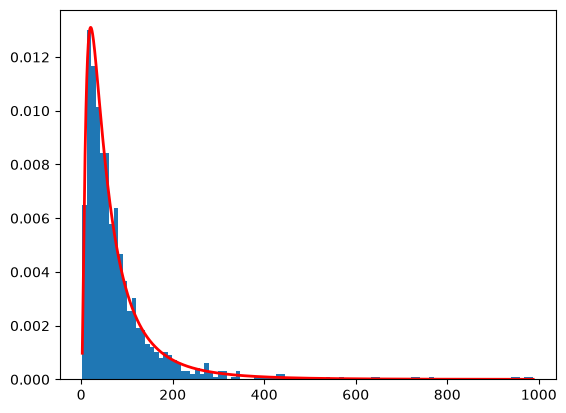

In [9]:
count, bins, _ = plt.hist(t_gen, 100, density=True, align='mid')
x = np.linspace(min(bins), max(bins), 10000)
pdf = (np.exp(-(np.log(x) - q)**2 / (2 * r**2))
       / (x * r * np.sqrt(2 * np.pi)))
plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

Importing csv with patients per stroke team data

In [11]:
df_b=pd.read_csv("stroke_team.csv")
c=df_b["stroke_team"]
np.random.seed(42)
patient_population=np.random.choice(c,num_samples,p=df_b["count"])

Converting it into a series

In [12]:
pp=pd.Series(patient_population)

In [13]:
pp.value_counts()

110    22
56     21
19     21
28     19
29     19
       ..
99      1
107     1
62      1
45      1
71      1
Name: count, Length: 113, dtype: int64

Hitsogram

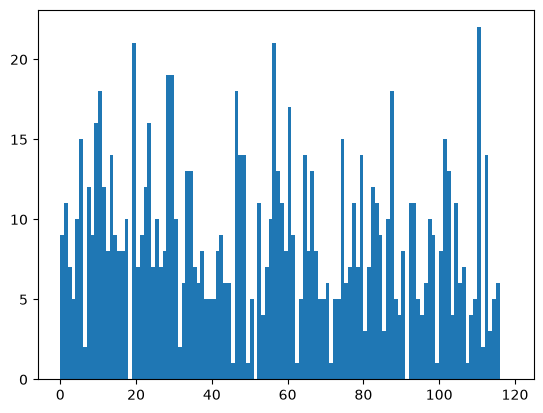

In [14]:
binsx=np.arange(0,120,1)
plt.hist(patient_population, bins=binsx)
plt.show()

Big code cell with the loop to run through all the columns

In [28]:
team_names=df_a.columns
f3=np.full(num_samples,42)

In [23]:
for i in team_names:
    m=df_a.loc["mu_for_lognorm", i]
    n=df_a.loc["sigma_for_lognorm", i]

    if int(i) in pp.value_counts().index:
        s=pp.value_counts()[int(i)]
    else:
        s=0

    f2 = np.random.default_rng()
    n_gen = f2.lognormal(m, n, size=s)

    inds_f2_0 = np.where(patient_population == int(i))
    f3[inds_f2_0] = n_gen
    
    #count, bins, _ = plt.hist(n_gen, 100, density=True, align='mid')
    #x = np.linspace(min(bins), max(bins), 10000)
    #pdf = (np.exp(-(np.log(x) - m)**2 / (2 * n**2))
    #    / (x * n * np.sqrt(2 * np.pi)))
    
    #plt.plot(x, pdf, linewidth=2, color='r')
    #plt.title(f"Stroke team {i}")
    #plt.xlabel("Arrival to scan time (mins)")
    #plt.ylabel("Number of patients")
    #plt.axis('tight')
    #plt.show()

Combining both the generated data columns into one dataframe

In [24]:
results=pd.DataFrame([pp, f3]).T
results.columns=["Stroke team","Arrival to scan time"]

In [25]:
results

,Stroke team,Arrival to scan time
0,64,49
1,42,46
2,12,9
3,5,57
4,79,41
...,...,...
995,87,12
996,73,11
997,10,301
998,42,95


Making a histogram of the dataframe

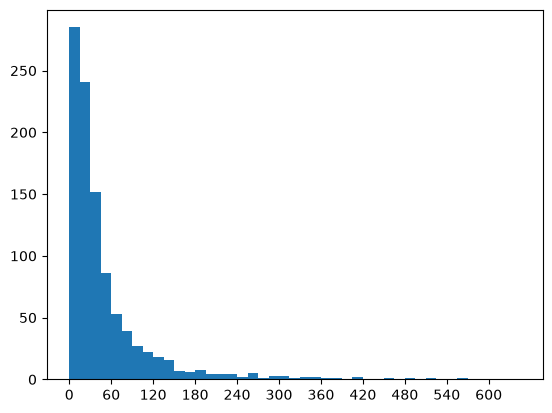

In [ ]:
binsx=np.arange(0,650,15)
plt.hist(results["Arrival to scan time"],bins=binsx)
plt.xticks(binsx[::4])#taking every 4th bins value as an xtick
plt.show()